In [2]:
# import necessary tools for spaital analysis
import pandas as pd
import geopandas as gpd
import contextily as ctx
import esda
from esda.moran import Moran, Moran_Local
import splot
from splot.esda import moran_scatterplot, plot_moran, lisa_cluster,plot_moran_simulation
import libpysal as lps
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
# import the data file, as well as reduce the number of and renaming the columns
blocks = gpd.read_file('../Group Data/acs2021_5yr_B01003_15000US060371041082.geojson')
blocks = blocks[['geoid','B01003001','geometry']]
blocks.columns = ['FIPS','Population','geometry']

In [4]:
# remove data pertaining to entire geography
blocks.drop(blocks.tail(1).index,inplace=True)

# sort by population
blocks.sort_values(by='Population').head(20)

# delete blocks with less than 100 people
blocks = blocks[blocks['Population']>100]

#
blocks = blocks.to_crs(epsg=3857)

In [5]:
oak = pd.read_csv('../Group Data/AllOaksinLACounty.csv')

In [6]:
oak = gpd.GeoDataFrame(oak, 
                         crs='EPSG:4326',
                         geometry=gpd.points_from_xy(oak.longitude, oak.latitude))
oak = oak.to_crs(epsg=3857)

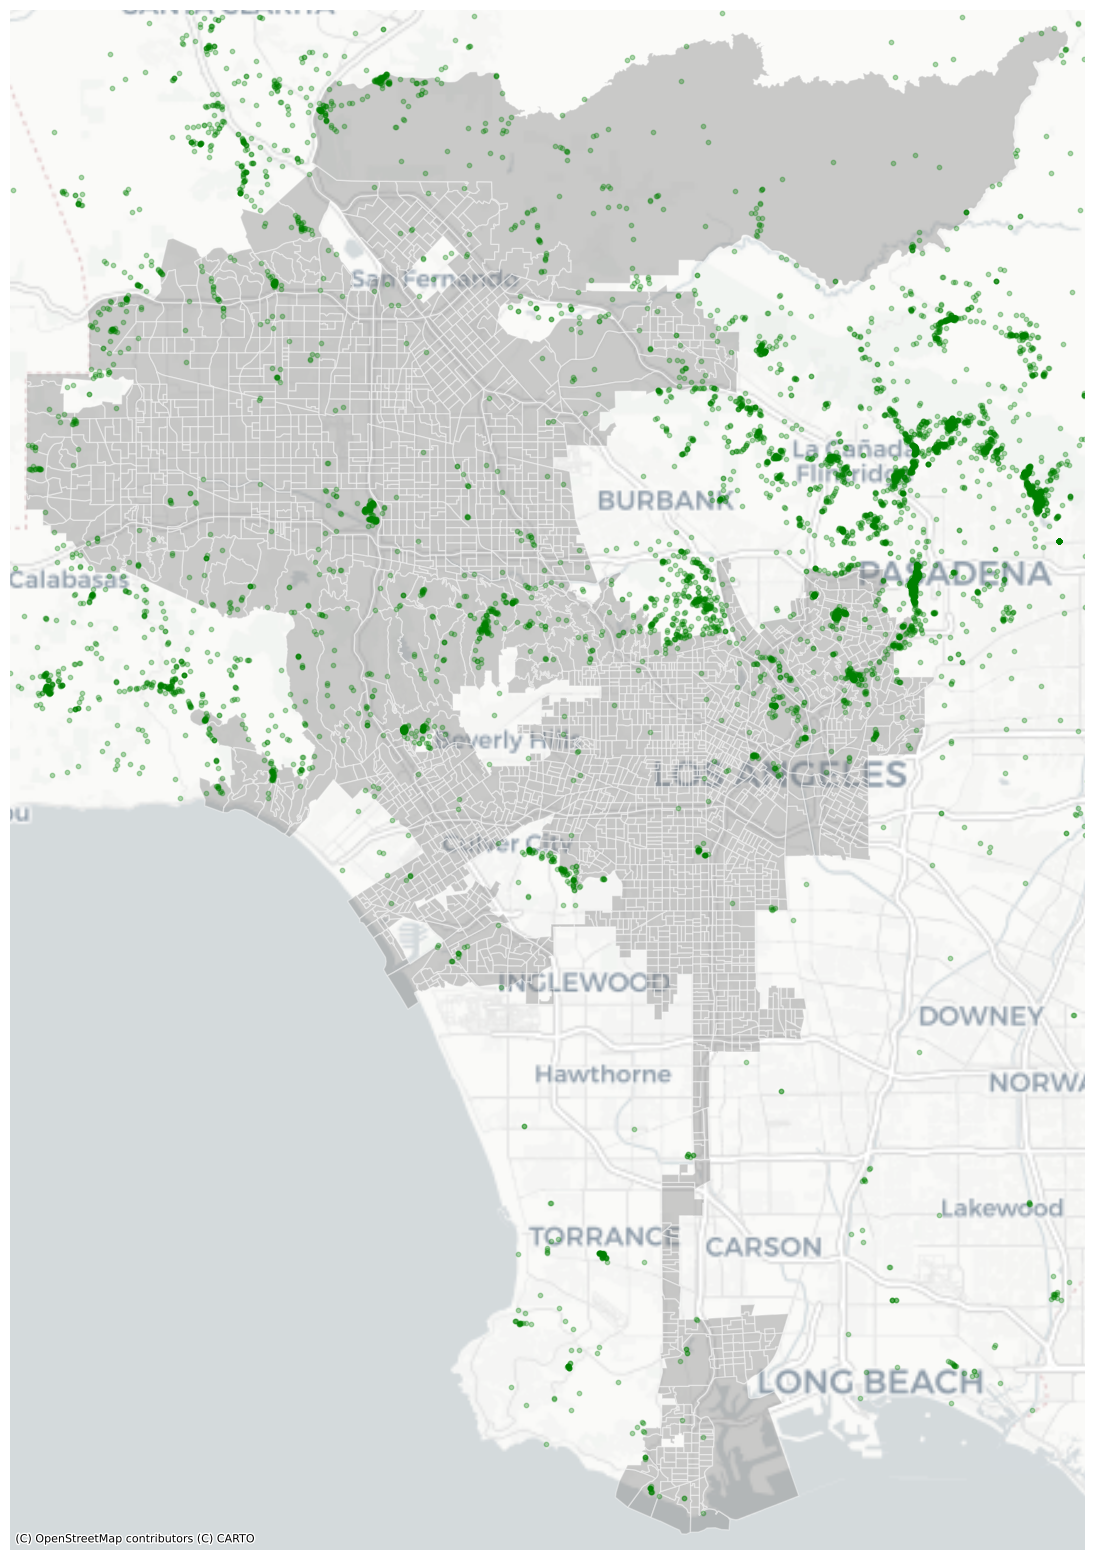

In [7]:
minx, miny, maxx, maxy = blocks.geometry.total_bounds
fig, ax = plt.subplots(figsize=(20, 20))
blocks.plot(ax=ax,
        color='gray', 
        edgecolor='white',
        alpha=0.4)
oak.plot(ax=ax, 
        color='green',
        markersize=10,
        alpha=0.3)
ax.set_xlim(minx - 1000, maxx + 1000)
ax.set_ylim(miny - 1000, maxy + 1000)
ax.axis('off')
ctx.add_basemap(ax,source=ctx.providers.CartoDB.Positron)
plt.savefig('Completed Maps/oaksoverlay.jpg')

In [8]:
# Do the spatial join
join = gpd.sjoin(blocks, oak, how='left')
oak_by_bg = join.FIPS.value_counts().rename_axis('FIPS').reset_index(name='oak_count')

In [9]:
blocks=blocks.merge(oak_by_bg,on='FIPS')

In [10]:
blocks['oak_per_1000'] = blocks['oak_count']/blocks['Population']*1000
blocks.sort_values(by="oak_per_1000").tail()

,FIPS,Population,geometry,oak_count,oak_per_1000
2189,15000US060372611041,1560.0,"MULTIPOLYGON (((-13182186.933 4043210.978, -13...",64,41.025641
1295,15000US060371993001,1204.0,"MULTIPOLYGON (((-13158577.293 4041596.805, -13...",89,73.920266
2666,15000US060379800101,109.0,"MULTIPOLYGON (((-13163713.575 4039600.478, -13...",46,422.018349
2664,15000US060379304002,532.0,"MULTIPOLYGON (((-13192132.662 4074373.822, -13...",243,456.766917
2669,15000US060379800241,200.0,"MULTIPOLYGON (((-13193418.068 4053521.172, -13...",122,610.000000


In [11]:
# calculate spatial weight
wq =  lps.weights.KNN.from_dataframe(blocks,k=8)

# Row-standardization
wq.transform = 'r'

# create a new column for the spatial lag
blocks['oak_per_1000_lag'] = lps.weights.lag_spatial(wq, blocks['oak_per_1000'])

# create a column that calculates the difference between arrests and lag
blocks['oak_lag_diff'] = blocks['oak_per_1000'] - blocks['oak_per_1000_lag']

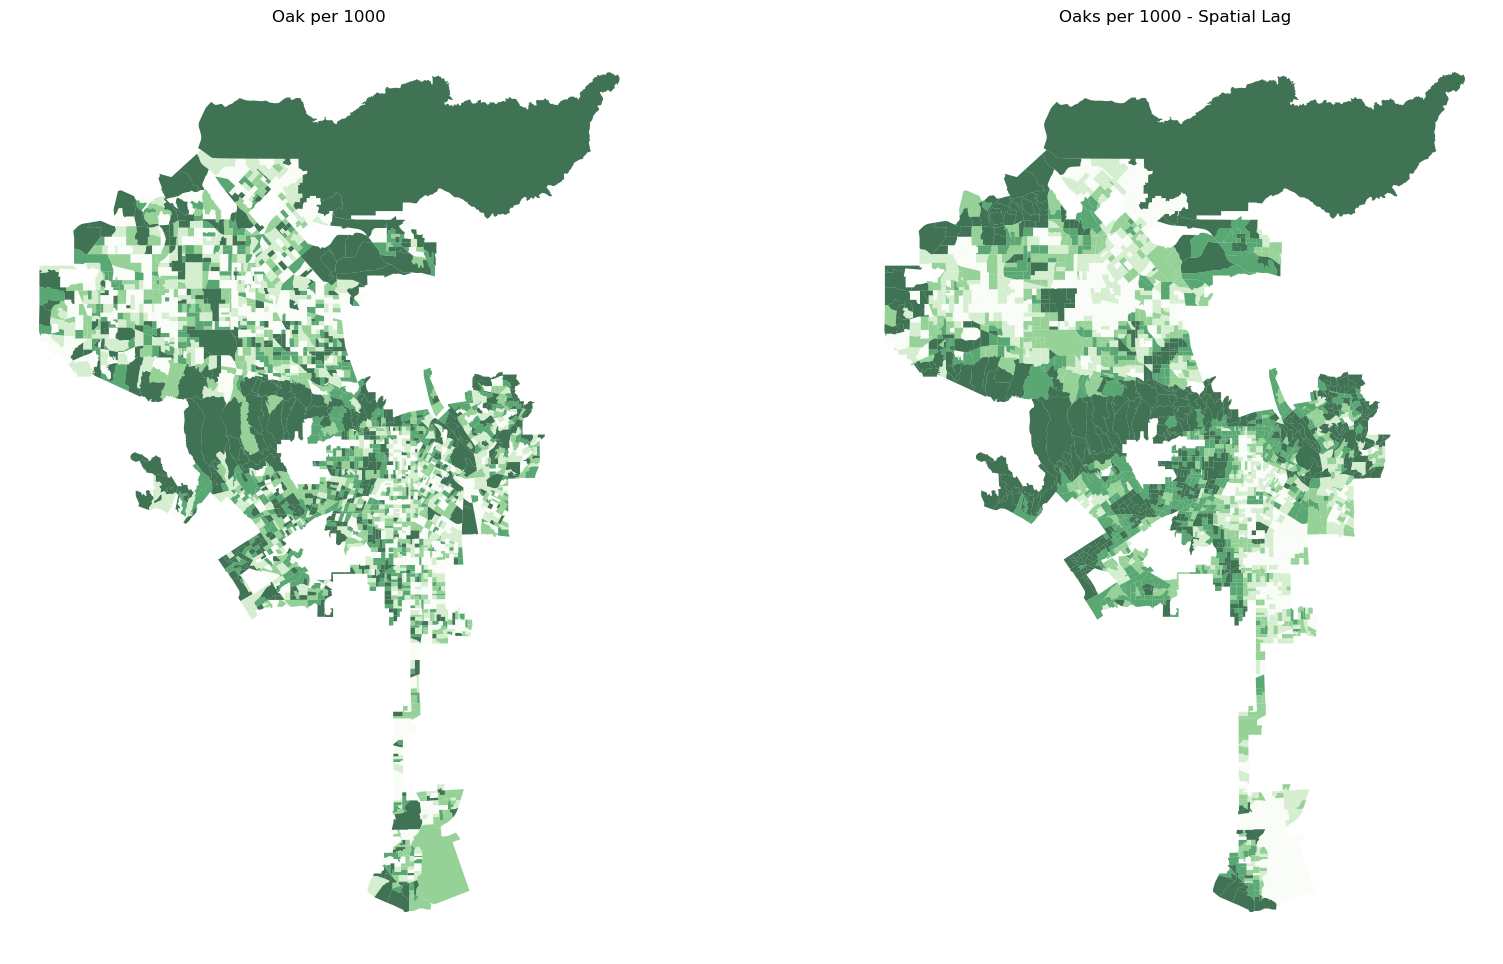

<Figure size 640x480 with 0 Axes>

In [14]:
# create the 1x2 subplots
fig, ax = plt.subplots(1, 2, figsize=(20, 12))

# two subplots produces ax[0] (left) and ax[1] (right)

# regular count map on the left
blocks.plot(ax=ax[0], # this assigns the map to the left subplot
         column='oak_per_1000', 
         cmap='Greens', 
         scheme='quantiles',
         k=5, 
         edgecolor='white', 
         linewidth=0, 
         alpha=0.75, 
           )


ax[0].axis("off")
ax[0].set_title("Oak per 1000")

# spatial lag map on the right
blocks.plot(ax=ax[1], # this assigns the map to the right subplot
         column='oak_per_1000_lag', 
         cmap='Greens', 
         scheme='quantiles',
         k=5, 
         edgecolor='white', 
         linewidth=0, 
         alpha=0.75
           )

ax[1].axis("off")
ax[1].set_title("Oaks per 1000 - Spatial Lag")

plt.show()
plt.savefig('Completed Maps/oaksspatiallag.jpg')

In [20]:
blocks.explore(
        column='oak_per_1000_lag',
        legend=True,
        cmap='Greens',
        scheme='naturalbreaks',
        style_kwds={
            'weight':0.5,
            'color':'black',
            'opacity':0.5
        },
        tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        attr='Tiles &copy; Esri &mdash; Source: Esri, i-cubed, USDA, USGS, AEX, GeoEye, Getmapping, Aerogrid, IGN, IGP, UPR-EGP, and the GIS User Community'
        )

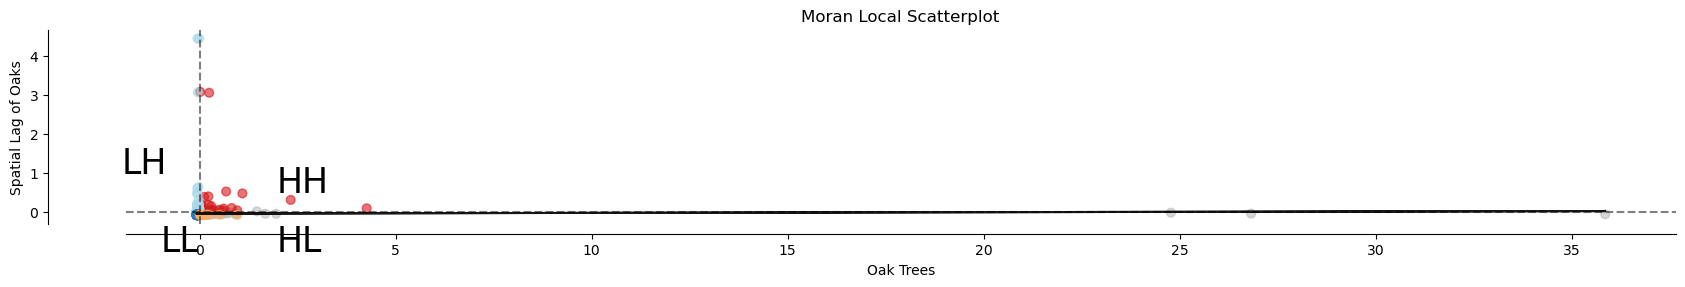

<Figure size 640x480 with 0 Axes>

In [17]:
y = blocks.oak_per_1000
moran = Moran(y, wq)
moran.I
lisa = esda.moran.Moran_Local(y, wq)

fig,ax = plt.subplots(figsize=(20,15))

moran_scatterplot(lisa, ax=ax, p=0.05)
ax.set_xlabel("Oak Trees")
ax.set_ylabel('Spatial Lag of Oaks')

# add some labels
plt.text(1.95, 0.5, "HH", fontsize=25)
plt.text(1.95, -1, "HL", fontsize=25)
plt.text(-2, 1, "LH", fontsize=25)
plt.text(-1, -1, "LL", fontsize=25)
plt.show()
plt.savefig('Completed Maps/oaksmoran.jpg')

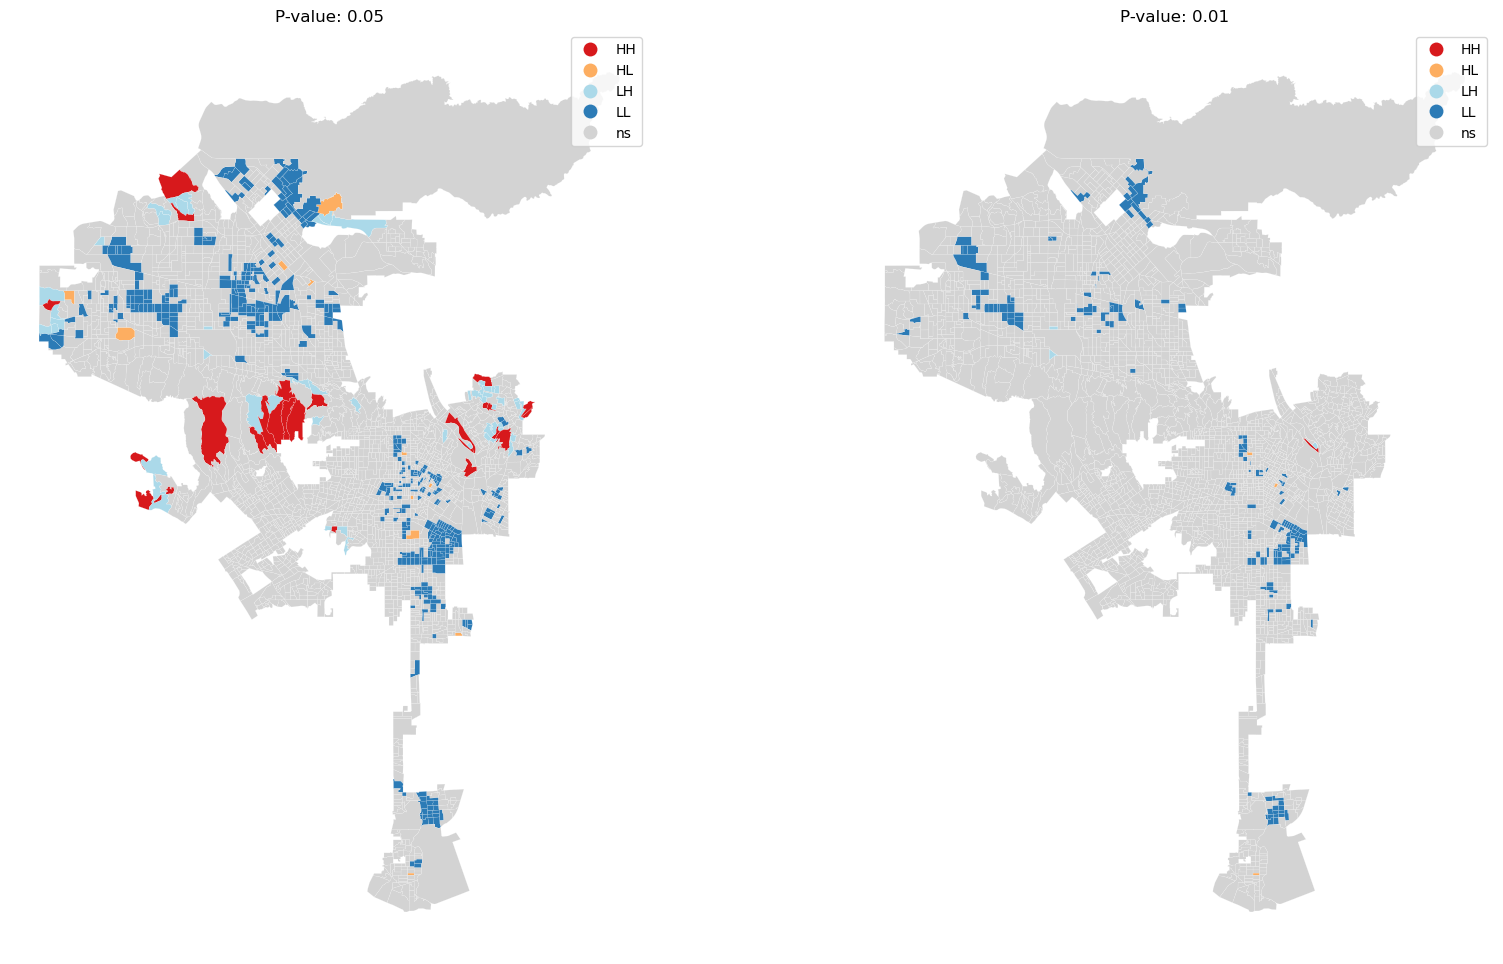

<Figure size 640x480 with 0 Axes>

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(20, 12))
lisa_cluster(lisa, blocks, p=0.05, ax=ax[0])
ax[0].axis("off")
ax[0].set_title("P-value: 0.05")
lisa_cluster(lisa, blocks, p=0.01, ax=ax[1])
ax[1].axis("off")
ax[1].set_title("P-value: 0.01")
plt.show()
plt.savefig('Completed Maps/oaksmoranmap.jpg')

**Division of Labor**

- Caroline: Notebook 1 (CarolineGroupAssignment4)
- Ethan: Notebook 2 (trinh_week8assignment)
- Will: Scheduled group meeting